This notebook provides a comparison between BANKSY and single-cell clustering (like PCA and Leiden). Specifically, I will implement Leiden clustering algorithm on the BANKSY example dataset, and compare results.

Key difference between BANKSY and Leiden:  
BANKSY uses spatial smoothing - includes data transformation (scaled using neighbor expression information). Goal is to integrate neighborhood information to enhance clustring results.  
Key steps in BANKSY include generating spatial graph and BANKSY-augmented matrix. BANKSY works with any clustering method (such as Leiden and K-means, the tutorial uses Leiden).  

Leiden, in comparison, uses k-NN graph, and is not aware of spatial neighbors. (so do NOT need location data)

Dataset used: BANKSY Slide-seq dataset example, already converted to AnnData format.

**BANKSY** See banksy_example.ipynb (need to run in the BANKSY folder environment)

**Normal Leiden Clustering**  
Here, I use the same dataset as banksy_example, and did the same data-preprocessing steps before running the Leiden algorithm.

In [5]:
import scanpy as sc
import pandas as pd

# load the dataset from Banksy folder (slideseqv1_cerebellum_adataraw.h5ad)
# note we do not need location information in traditional Leiden clustering
adata = sc.read_h5ad("../Banksy_py/data/slide_seq/v1/slideseqv1_cerebellum_adataraw.h5ad")

## PRE-PROCESSING
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# calculate QC metrics
sc.pp.calculate_qc_metrics(adata, 
                           qc_vars=["mt"], 
                           log1p=True, 
                           inplace=True)
# Filter cells with >5% mitochondrial gene expression
adata = adata[adata.obs.pct_counts_mt < 5, :]
# Filter genes expressed in fewer than 10 cells
sc.pp.filter_genes(adata, min_cells=10)


In [6]:
# Normalization and Further Processing
# Normalize total counts per cell to 10,000
sc.pp.normalize_total(adata, target_sum=1e4)
# Log-transform the data
sc.pp.log1p(adata)
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
# filter to only include highly variable genes
adata = adata[:, adata.var.highly_variable]
# scale the data (scale to have equal variance from each gene)
sc.pp.scale(adata, max_value=10)

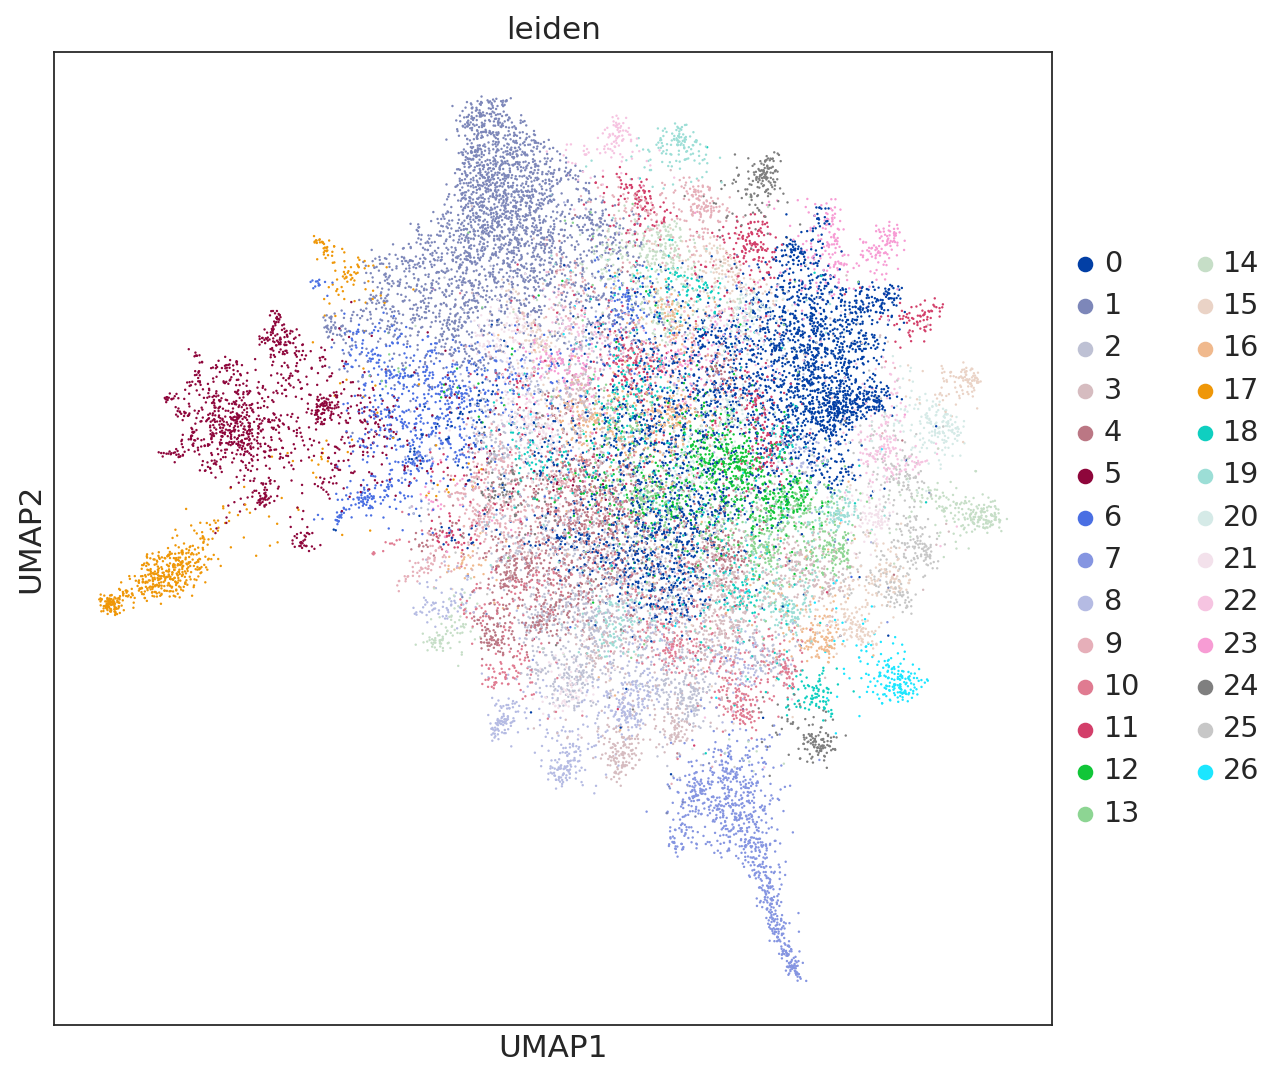

In [7]:
import numpy as np
import random
seed = 1234
np.random.seed(seed)
random.seed(seed)

# PCA
sc.tl.pca(adata, svd_solver='arpack')
# Compute neighborhood graph
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
# Cluster using Leiden
sc.tl.leiden(adata, resolution=0.5)
# Visualize
# Compute UMAP embedding
sc.tl.umap(adata)
# Plot UMAP
sc.pl.umap(adata, color=['leiden'])


For a more direct comparison, see BANKSY_example notebook. Towards the end of the notebook, 4 plots are shown: BANKSY labels (nonspatial) are generated without including neighbor information, while scaled_gaussian does include neighbor information.

Code applied for the non-spatial group: (similar as what is shown above, with more structure)

In [ ]:
# PCA
sc.tl.pca(banksy_dict['nonspatial'][0.0]['adata'])
# kNN graph construction
sc.pp.neighbors(banksy_dict['nonspatial'][0.0]['adata'], n_neighbors=15, n_pcs=40)
# Leiden Clustering
sc.tl.leiden(banksy_dict['nonspatial'][0.0]['adata'], resolution=0.5)
# UMAP visualization
sc.tl.umap(banksy_dict['nonspatial'][0.0]['adata'])
sc.pl.umap(banksy_dict['nonspatial'][0.0]['adata'], color='leiden')

Observations of results between BANKSY labels (non-spatial) and (scaled_gaussian) groups [The plots are in banksy_example.ipynb]:    
Physical Space: non-spatial physical plot looks more scattered. After inclusion of spatial neighbor information, clusters follow tissue morphology more clearly.  
UMAP Plots: non-spatial clusters appear more spread out, mixtures of clusters appear - cell types less separated. Scaled_gaussian clusters are well separated. (and preserve local spatial relationship in the UMAP space)  
PCA Scatterplots: more compact PCA distributions and less random scattering of points after BANKSY  
Connectivity map: scattered interactions without BANKSY, noise exist. With BANKSY, stronger diagonal patterns, more explained separation between clusters.  
UMAP Embeddings: Clusters are more compact after BANKSY, less mixing with other regions. (preserve major tissue structure)